# Exploratory Data Analysis — Fake News Detection
## WELFake Dataset
**Name:** Pulindu Pasanjith  
**Dataset:** WELFake — 72,134 news articles  
**Goal:** Understand the data distribution, word patterns, and class balance before model training.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print("✅ Libraries imported!")

✅ Libraries imported!


In [3]:
df = pd.read_csv('../data/welFake_cleaned.csv')

print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (72095, 2)

Column names: ['final_text', 'label']

First 5 rows:


,final_text,label
0,law enforcement high alert following threat co...,1
1,post vote hillary already,1
2,unbelievable obamas attorney general say charl...,1
3,bobby jindal raised hindu us story christian c...,0
4,satan russia unvelis image terrifying new supe...,1


## 1. Data Overview
Understanding the basic structure and content of the dataset.

In [4]:
print("Total articles:", len(df))
print("\nLabel distribution:")
print(df['label'].value_counts())
print("\nMissing values:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)

Total articles: 72095

Label distribution:
label
1    37067
0    35028
Name: count, dtype: int64

Missing values:
final_text    54
label          0
dtype: int64

Data types:
final_text    object
label          int64
dtype: object


## 2. Class Distribution
Checking if the dataset is balanced between fake and real news.

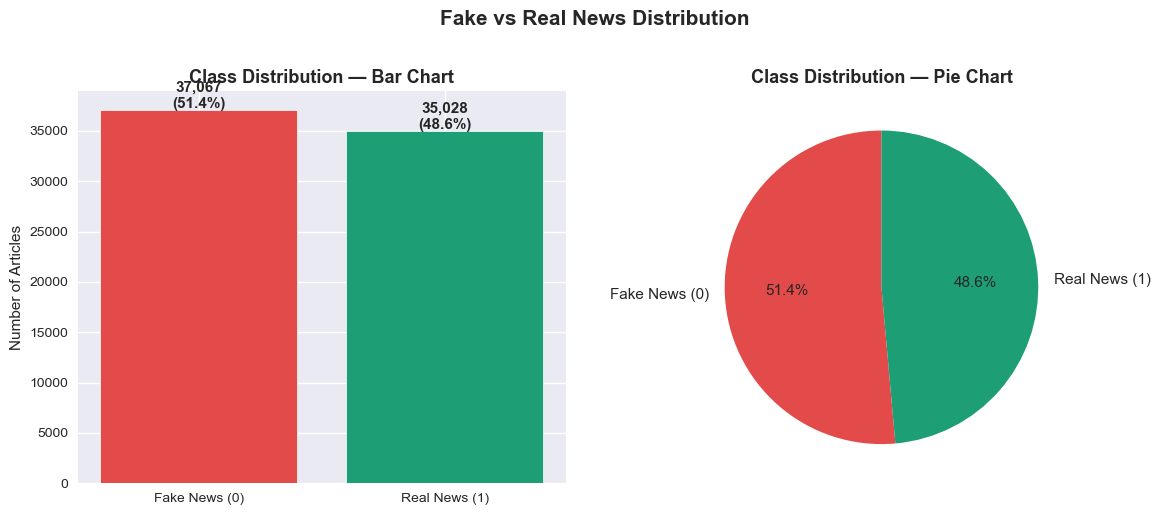

✅ Chart saved to screenshots folder!


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ['#E24B4A', '#1D9E75']
counts = df['label'].value_counts()
labels = ['Fake News (0)', 'Real News (1)']

axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Class Distribution — Bar Chart', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Articles')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}\n({v/len(df)*100:.1f}%)', 
                ha='center', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Class Distribution — Pie Chart', fontsize=13, fontweight='bold')

plt.suptitle('Fake vs Real News Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../screenshots/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to screenshots folder!")